In [1]:
# ============================================================
# CELDA 1 - Instalacion e importacion de librerias
# Proyecto: Prediccion de Riesgo Crediticio
# Dataset: Give Me Some Credit (OpenML ID: 43454)
# ============================================================

# Manipulacion de datos
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estadistica
from scipy import stats

# Machine Learning y acceso a datos
from sklearn.datasets import fetch_openml

# Configuracion global
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("Librerias importadas correctamente")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   seaborn    : {sns.__version__}")

Librerias importadas correctamente
   pandas     : 2.2.2
   numpy      : 2.0.2
   seaborn    : 0.13.2


In [2]:
# ============================================================
# CELDA 2 - Obtencion de datos via API publica (OpenML)
# Fuente: https://www.openml.org/d/43454
# Dataset: Give Me Some Credit
# ============================================================

# NOTA: Comentar este bloque tras la primera ejecucion exitosa

print("Descargando dataset desde OpenML API...")

dataset = fetch_openml(
    data_id=43454,
    as_frame=True,
    parser='auto'
)

# DataFrame completo
df_raw = dataset.frame

print(f"Descarga exitosa")
print(f"   Filas    : {df_raw.shape[0]:,}")
print(f"   Columnas : {df_raw.shape[1]}")

# Guardado local en CSV
ruta_local = 'give_me_some_credit_raw.csv'
df_raw.to_csv(ruta_local, index=False)
print(f"Dataset guardado localmente en: '{ruta_local}'")

# Una vez descargado, puedes comentar el bloque anterior
# y usar esta linea en su lugar:
# df_raw = pd.read_csv('give_me_some_credit_raw.csv')

Descargando dataset desde OpenML API...
Descarga exitosa
   Filas    : 32,581
   Columnas : 12
Dataset guardado localmente en: 'give_me_some_credit_raw.csv'


In [3]:
# ============================================================
# CELDA 3 - Auditoria inicial del dataset
# ============================================================

print("AUDITORIA INICIAL - CREDIT RISK DATASET")
print("-" * 50)

# 1. Dimensiones
print("DIMENSIONES:")
print(df_raw.shape)

# 2. Tipos de datos y nulos
print("\nESTRUCTURA DE VARIABLES:")
auditoria = pd.DataFrame({
    'Tipo': df_raw.dtypes,
    'Nulos': df_raw.isnull().sum(),
    'Nulos_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'Valores_unicos': df_raw.nunique()
})
print(auditoria.to_string())

# 3. Estadisticas descriptivas
print("\nESTADISTICAS DESCRIPTIVAS:")
print(df_raw.describe().T.to_string())

# 4. Distribucion variable objetivo
print("\nDISTRIBUCION VARIABLE OBJETIVO (loan_status):")
conteo = df_raw['loan_status'].value_counts()
pct = df_raw['loan_status'].value_counts(normalize=True) * 100

print("Sin default (0):", conteo[0], "-", round(pct[0], 2), "%")
print("Con default (1):", conteo[1], "-", round(pct[1], 2), "%")

ratio = round(conteo[0] / conteo[1], 1)
print("Ratio de desbalance:", ratio, ":1")

AUDITORIA INICIAL - CREDIT RISK DATASET
--------------------------------------------------
DIMENSIONES:
(32581, 12)

ESTRUCTURA DE VARIABLES:
                               Tipo  Nulos  Nulos_pct  Valores_unicos
person_age                    int64      0     0.0000              58
person_income                 int64      0     0.0000            4295
person_home_ownership        object      0     0.0000               4
person_emp_length           float64    895     2.7500              36
loan_intent                  object      0     0.0000               6
loan_grade                   object      0     0.0000               7
loan_amnt                     int64      0     0.0000             753
loan_int_rate               float64   3116     9.5600             348
loan_status                   int64      0     0.0000               2
loan_percent_income         float64      0     0.0000              77
cb_person_default_on_file    object      0     0.0000               2
cb_person_cred_his

In [4]:
# ============================================================
# CELDA 4 - Limpieza de datos
# ============================================================

# Copiamos el dataframe original para no modificarlo
df = df_raw.copy()

print("LIMPIEZA DE DATOS")
print("-" * 50)

# 1. Eliminar outliers imposibles en person_age
print("\n1. Outliers en person_age:")
print("   Registros con edad > 90:", (df['person_age'] > 90).sum())
df = df[df['person_age'] <= 90]
print("   Eliminados. Filas restantes:", len(df))

# 2. Eliminar outliers imposibles en person_emp_length
print("\n2. Outliers en person_emp_length:")
print("   Registros con empleo > 60 anios:", (df['person_emp_length'] > 60).sum())
df = df[df['person_emp_length'] <= 60]
print("   Eliminados. Filas restantes:", len(df))

# 3. Eliminar outliers extremos en person_income
limite_ingreso = df['person_income'].quantile(0.99)
print("\n3. Outliers en person_income:")
print("   Limite percentil 99:", limite_ingreso)
print("   Registros sobre ese limite:", (df['person_income'] > limite_ingreso).sum())
df = df[df['person_income'] <= limite_ingreso]
print("   Eliminados. Filas restantes:", len(df))

# 4. Imputar nulos en loan_int_rate con la mediana
print("\n4. Nulos en loan_int_rate:")
mediana_tasa = df['loan_int_rate'].median()
print("   Mediana de tasa:", mediana_tasa)
df['loan_int_rate'] = df['loan_int_rate'].fillna(mediana_tasa)
print("   Nulos imputados con mediana")

# 5. Imputar nulos en person_emp_length con la mediana
print("\n5. Nulos en person_emp_length:")
mediana_emp = df['person_emp_length'].median()
print("   Mediana de empleo:", mediana_emp)
df['person_emp_length'] = df['person_emp_length'].fillna(mediana_emp)
print("   Nulos imputados con mediana")

# 6. Verificacion final
print("\nVERIFICACION FINAL:")
print("   Filas finales  :", len(df))
print("   Nulos restantes:", df.isnull().sum().sum())
print("   Outliers edad > 90:", (df['person_age'] > 90).sum())
print("\nLimpieza completada exitosamente")

LIMPIEZA DE DATOS
--------------------------------------------------

1. Outliers en person_age:
   Registros con edad > 90: 6
   Eliminados. Filas restantes: 32575

2. Outliers en person_emp_length:
   Registros con empleo > 60 anios: 2
   Eliminados. Filas restantes: 31678

3. Outliers en person_income:
   Limite percentil 99: 227614.99999999977
   Registros sobre ese limite: 317
   Eliminados. Filas restantes: 31361

4. Nulos en loan_int_rate:
   Mediana de tasa: 10.99
   Nulos imputados con mediana

5. Nulos en person_emp_length:
   Mediana de empleo: 4.0
   Nulos imputados con mediana

VERIFICACION FINAL:
   Filas finales  : 31361
   Nulos restantes: 0
   Outliers edad > 90: 0

Limpieza completada exitosamente


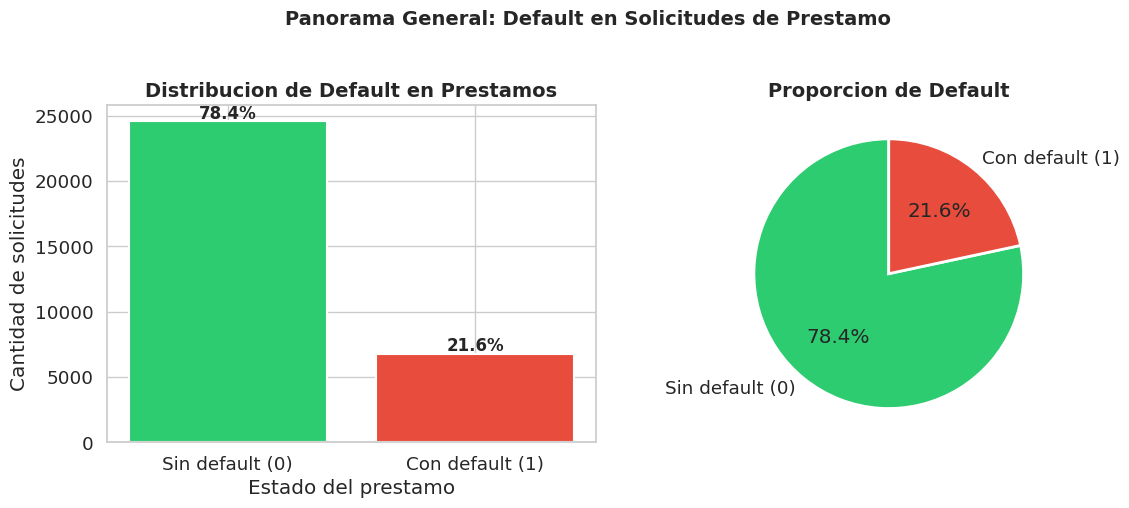

Insight:
El 21.8% de los solicitantes incurrio en default.
El dataset tiene un desbalance moderado de 3.6:1
Imagen guardada como viz1_distribucion_default.png


In [5]:
# ============================================================
# CELDA 5 - Visualizacion 1: Distribucion de variable objetivo
# Pregunta: Como se distribuyen los casos de default?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Datos
conteo = df['loan_status'].value_counts()
etiquetas = ['Sin default (0)', 'Con default (1)']
colores = ['#2ecc71', '#e74c3c']
valores = [conteo[0], conteo[1]]
porcentajes = [round(conteo[0]/len(df)*100, 1), round(conteo[1]/len(df)*100, 1)]

# Grafico 1 - Barras
axes[0].bar(etiquetas, valores, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribucion de Default en Prestamos')
axes[0].set_ylabel('Cantidad de solicitudes')
axes[0].set_xlabel('Estado del prestamo')
for i, (v, p) in enumerate(zip(valores, porcentajes)):
    axes[0].text(i, v + 200, str(p) + '%', ha='center', fontweight='bold', fontsize=12)

# Grafico 2 - Pie
axes[1].pie(valores, labels=etiquetas, colors=colores,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporcion de Default')

plt.suptitle('Panorama General: Default en Solicitudes de Prestamo',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz1_distribucion_default.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight:")
print("El 21.8% de los solicitantes incurrio en default.")
print("El dataset tiene un desbalance moderado de 3.6:1")
print("Imagen guardada como viz1_distribucion_default.png")

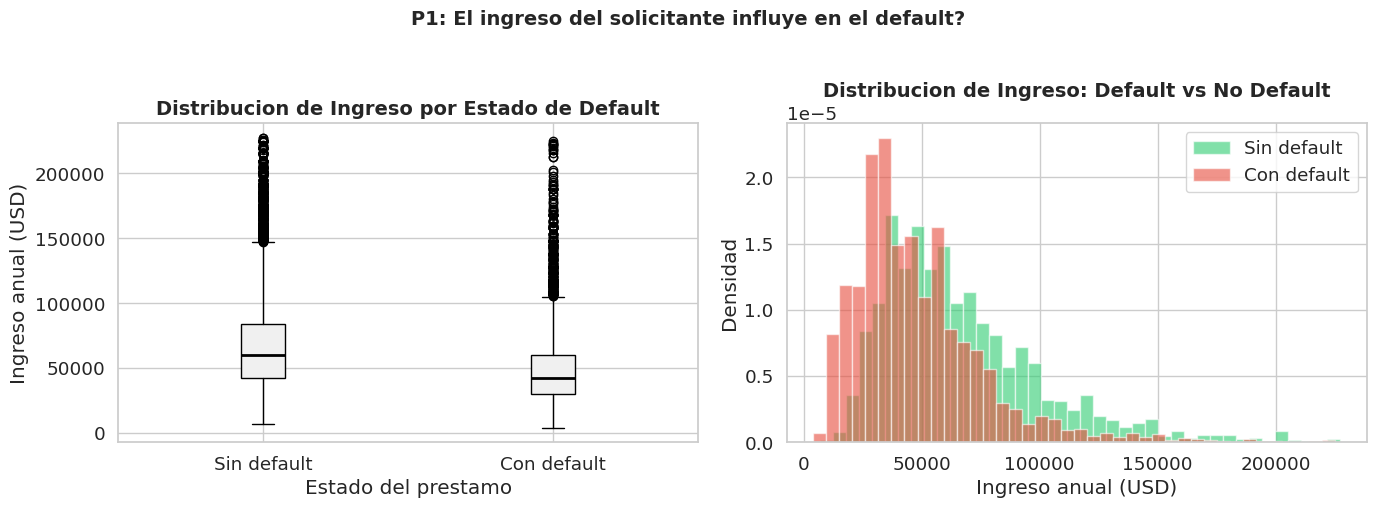

TEST ESTADISTICO - Mann-Whitney U:
   Mediana ingreso sin default: 60000.0
   Mediana ingreso con default: 42000.0
   p-value: 0.0
   Conclusion: Diferencia estadisticamente significativa (p < 0.05)


In [6]:
# ============================================================
# CELDA 6 - Visualizacion 2: Ingreso vs Default
# Pregunta P1: Los solicitantes con menor ingreso tienen
# mayor probabilidad de default?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos separados por grupo
sin_default = df[df['loan_status'] == 0]['person_income']
con_default = df[df['loan_status'] == 1]['person_income']

colores = ['#2ecc71', '#e74c3c']

# Grafico 1 - Boxplot comparativo
axes[0].boxplot([sin_default, con_default],
                labels=['Sin default', 'Con default'],
                patch_artist=True,
                boxprops=dict(facecolor='#f0f0f0'),
                medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Distribucion de Ingreso por Estado de Default')
axes[0].set_ylabel('Ingreso anual (USD)')
axes[0].set_xlabel('Estado del prestamo')

# Grafico 2 - Histograma superpuesto
axes[1].hist(sin_default, bins=40, alpha=0.6, color='#2ecc71',
             label='Sin default', density=True)
axes[1].hist(con_default, bins=40, alpha=0.6, color='#e74c3c',
             label='Con default', density=True)
axes[1].set_title('Distribucion de Ingreso: Default vs No Default')
axes[1].set_xlabel('Ingreso anual (USD)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('P1: El ingreso del solicitante influye en el default?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz2_ingreso_default.png', dpi=150, bbox_inches='tight')
plt.show()

# Test estadistico
stat, pvalue = stats.mannwhitneyu(sin_default, con_default, alternative='two-sided')
print("TEST ESTADISTICO - Mann-Whitney U:")
print("   Mediana ingreso sin default:", round(sin_default.median(), 2))
print("   Mediana ingreso con default:", round(con_default.median(), 2))
print("   p-value:", round(pvalue, 6))
if pvalue < 0.05:
    print("   Conclusion: Diferencia estadisticamente significativa (p < 0.05)")
else:
    print("   Conclusion: No hay diferencia significativa (p >= 0.05)")

<function matplotlib.pyplot.show(close=None, block=None)>

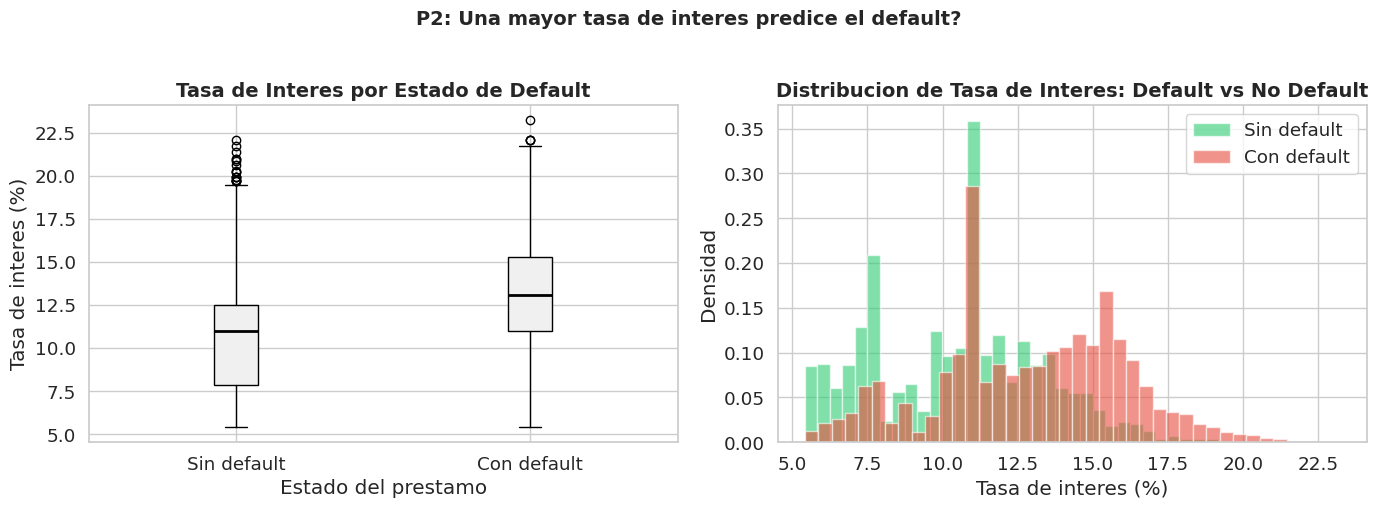

In [7]:
# ============================================================
# CELDA 7 - Visualizacion 3: Tasa de interes vs Default
# Pregunta P2: Los prestamos con mayor tasa de interes
# tienen mayor riesgo de default?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos separados por grupo
sin_default = df[df['loan_status'] == 0]['loan_int_rate']
con_default = df[df['loan_status'] == 1]['loan_int_rate']

# Grafico 1 - Boxplot comparativo
axes[0].boxplot([sin_default, con_default],
                labels=['Sin default', 'Con default'],
                patch_artist=True,
                boxprops=dict(facecolor='#f0f0f0'),
                medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Tasa de Interes por Estado de Default')
axes[0].set_ylabel('Tasa de interes (%)')
axes[0].set_xlabel('Estado del prestamo')

# Grafico 2 - Histograma superpuesto
axes[1].hist(sin_default, bins=40, alpha=0.6, color='#2ecc71',
             label='Sin default', density=True)
axes[1].hist(con_default, bins=40, alpha=0.6, color='#e74c3c',
             label='Con default', density=True)
axes[1].set_title('Distribucion de Tasa de Interes: Default vs No Default')
axes[1].set_xlabel('Tasa de interes (%)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('P2: Una mayor tasa de interes predice el default?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz3_tasa_default.png', dpi=150, bbox_inches='tight')
plt.show

In [8]:
# ============================================================
# CELDA 7B - Test estadistico P2: Tasa de interes vs Default
# ============================================================

sin_default = df[df['loan_status'] == 0]['loan_int_rate']
con_default = df[df['loan_status'] == 1]['loan_int_rate']

stat, pvalue = stats.mannwhitneyu(sin_default, con_default, alternative='two-sided')

print("TEST ESTADISTICO - Mann-Whitney U:")
print("   Mediana tasa sin default:", round(sin_default.median(), 2))
print("   Mediana tasa con default:", round(con_default.median(), 2))
print("   p-value:", round(pvalue, 6))

if pvalue < 0.05:
    print("   Conclusion: Diferencia estadisticamente significativa (p < 0.05)")
else:
    print("   Conclusion: No hay diferencia significativa (p >= 0.05)")

TEST ESTADISTICO - Mann-Whitney U:
   Mediana tasa sin default: 10.99
   Mediana tasa con default: 13.06
   p-value: 0.0
   Conclusion: Diferencia estadisticamente significativa (p < 0.05)


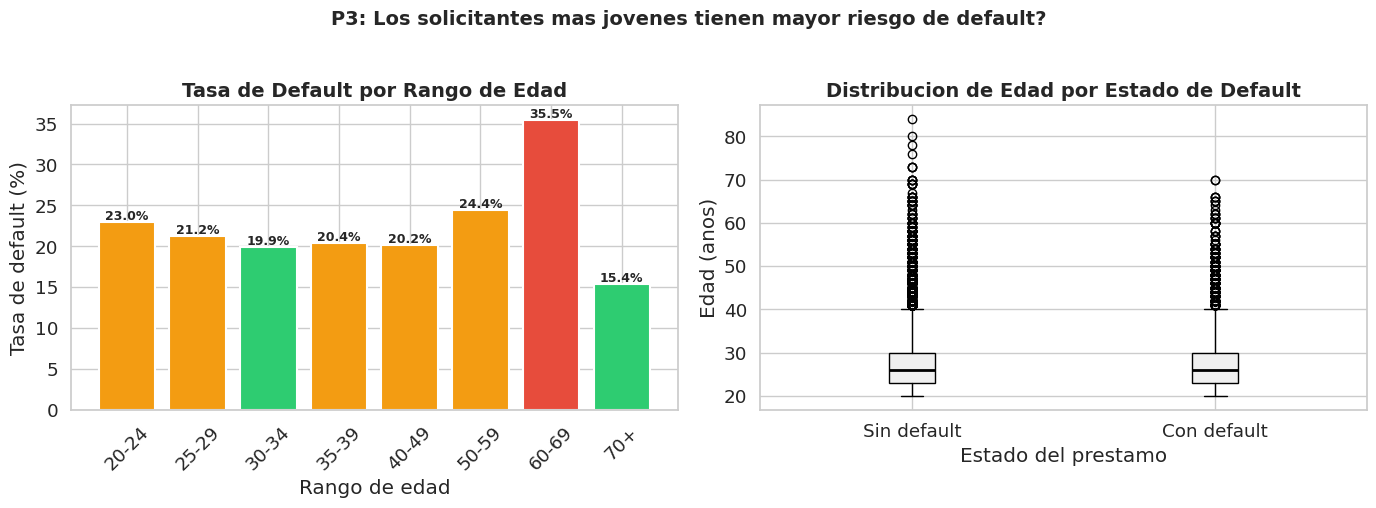

In [9]:
# ============================================================
# CELDA 8 - Visualizacion 4: Edad vs Default
# Pregunta P3: Los solicitantes mas jovenes tienen mayor
# tasa de default?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Crear rangos de edad
bins = [20, 25, 30, 35, 40, 50, 60, 70, 90]
etiquetas_edad = ['20-24', '25-29', '30-34', '35-39', '40-49', '50-59', '60-69', '70+']

df['rango_edad'] = pd.cut(df['person_age'], bins=bins, labels=etiquetas_edad, right=False)

# Tasa de default por rango de edad
tasa_default = df.groupby('rango_edad', observed=True)['loan_status'].mean() * 100
conteo_edad = df.groupby('rango_edad', observed=True)['loan_status'].count()

# Grafico 1 - Tasa de default por rango de edad
colores_barras = ['#e74c3c' if t > 25 else '#f39c12' if t > 20 else '#2ecc71'
                  for t in tasa_default.values]
axes[0].bar(tasa_default.index, tasa_default.values,
            color=colores_barras, edgecolor='white', linewidth=1.5)
axes[0].set_title('Tasa de Default por Rango de Edad')
axes[0].set_ylabel('Tasa de default (%)')
axes[0].set_xlabel('Rango de edad')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(tasa_default.values):
    axes[0].text(i, v + 0.3, str(round(v, 1)) + '%',
                 ha='center', fontsize=9, fontweight='bold')

# Grafico 2 - Boxplot edad por estado de default
sin_default_edad = df[df['loan_status'] == 0]['person_age']
con_default_edad = df[df['loan_status'] == 1]['person_age']

axes[1].boxplot([sin_default_edad, con_default_edad],
                labels=['Sin default', 'Con default'],
                patch_artist=True,
                boxprops=dict(facecolor='#f0f0f0'),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Distribucion de Edad por Estado de Default')
axes[1].set_ylabel('Edad (anos)')
axes[1].set_xlabel('Estado del prestamo')

plt.suptitle('P3: Los solicitantes mas jovenes tienen mayor riesgo de default?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz4_edad_default.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# CELDA 8B - Test estadistico P3: Edad vs Default
# ============================================================

sin_default_edad = df[df['loan_status'] == 0]['person_age']
con_default_edad = df[df['loan_status'] == 1]['person_age']

stat, pvalue = stats.mannwhitneyu(sin_default_edad, con_default_edad, alternative='two-sided')

print("TEST ESTADISTICO - Mann-Whitney U:")
print("   Mediana edad sin default:", round(sin_default_edad.median(), 1))
print("   Mediana edad con default:", round(con_default_edad.median(), 1))
print("   p-value:", round(pvalue, 6))

if pvalue < 0.05:
    print("   Conclusion: Diferencia estadisticamente significativa (p < 0.05)")
else:
    print("   Conclusion: No hay diferencia significativa (p >= 0.05)")

print("\nTASA DE DEFAULT POR RANGO DE EDAD:")
tasa_default = df.groupby('rango_edad', observed=True)['loan_status'].mean() * 100
for rango, tasa in tasa_default.items():
    print("   " + str(rango) + ": " + str(round(tasa, 1)) + "%")

TEST ESTADISTICO - Mann-Whitney U:
   Mediana edad sin default: 26.0
   Mediana edad con default: 26.0
   p-value: 0.0
   Conclusion: Diferencia estadisticamente significativa (p < 0.05)

TASA DE DEFAULT POR RANGO DE EDAD:
   20-24: 23.0%
   25-29: 21.2%
   30-34: 19.9%
   35-39: 20.4%
   40-49: 20.2%
   50-59: 24.4%
   60-69: 35.5%
   70+: 15.4%


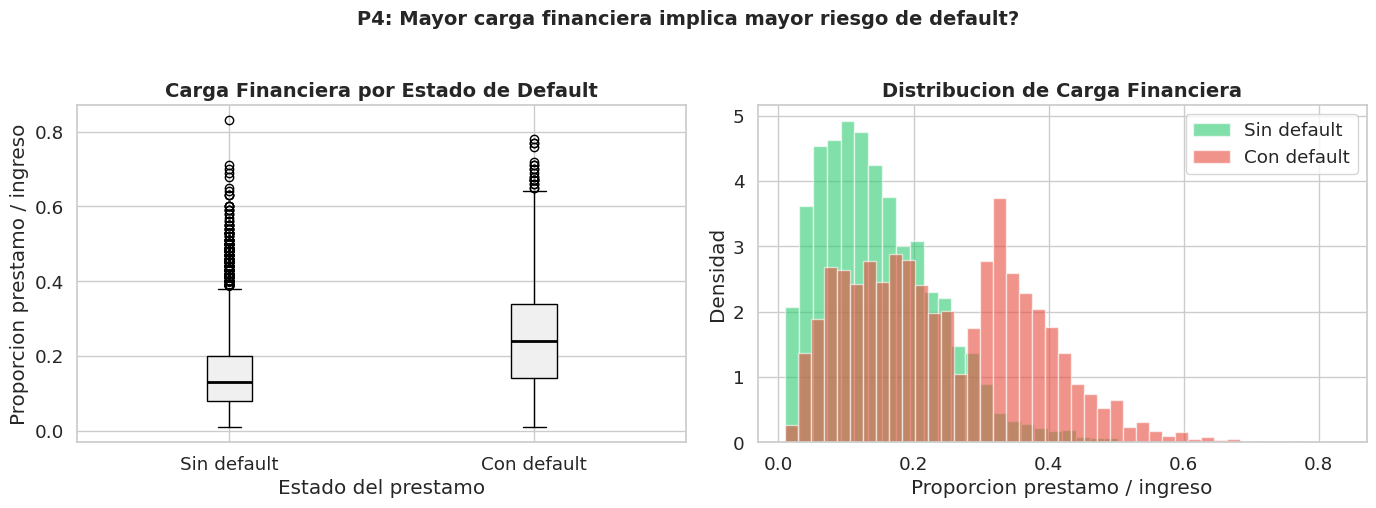

In [11]:
# ============================================================
# CELDA 9 - Visualizacion 5: Carga financiera vs Default
# Pregunta P4: Una mayor proporcion prestamo/ingreso
# aumenta el riesgo de default?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos
sin_default = df[df['loan_status'] == 0]['loan_percent_income']
con_default = df[df['loan_status'] == 1]['loan_percent_income']

# Grafico 1 - Boxplot comparativo
axes[0].boxplot([sin_default, con_default],
                labels=['Sin default', 'Con default'],
                patch_artist=True,
                boxprops=dict(facecolor='#f0f0f0'),
                medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Carga Financiera por Estado de Default')
axes[0].set_ylabel('Proporcion prestamo / ingreso')
axes[0].set_xlabel('Estado del prestamo')

# Grafico 2 - Histograma superpuesto
axes[1].hist(sin_default, bins=40, alpha=0.6, color='#2ecc71',
             label='Sin default', density=True)
axes[1].hist(con_default, bins=40, alpha=0.6, color='#e74c3c',
             label='Con default', density=True)
axes[1].set_title('Distribucion de Carga Financiera')
axes[1].set_xlabel('Proporcion prestamo / ingreso')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('P4: Mayor carga financiera implica mayor riesgo de default?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz5_carga_default.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# CELDA 9B - Test estadistico P4: Carga financiera vs Default
# ============================================================

sin_default = df[df['loan_status'] == 0]['loan_percent_income']
con_default = df[df['loan_status'] == 1]['loan_percent_income']

stat, pvalue = stats.mannwhitneyu(sin_default, con_default, alternative='two-sided')

print("TEST ESTADISTICO - Mann-Whitney U:")
print("   Mediana carga sin default:", round(sin_default.median(), 3))
print("   Mediana carga con default:", round(con_default.median(), 3))
print("   p-value:", round(pvalue, 6))

if pvalue < 0.05:
    print("   Conclusion: Diferencia estadisticamente significativa (p < 0.05)")
else:
    print("   Conclusion: No hay diferencia significativa (p >= 0.05)")

# Diferencia porcentual
diff = ((con_default.median() - sin_default.median()) / sin_default.median()) * 100
print("   Diferencia relativa:", round(diff, 1), "%")

TEST ESTADISTICO - Mann-Whitney U:
   Mediana carga sin default: 0.13
   Mediana carga con default: 0.24
   p-value: 0.0
   Conclusion: Diferencia estadisticamente significativa (p < 0.05)
   Diferencia relativa: 84.6 %


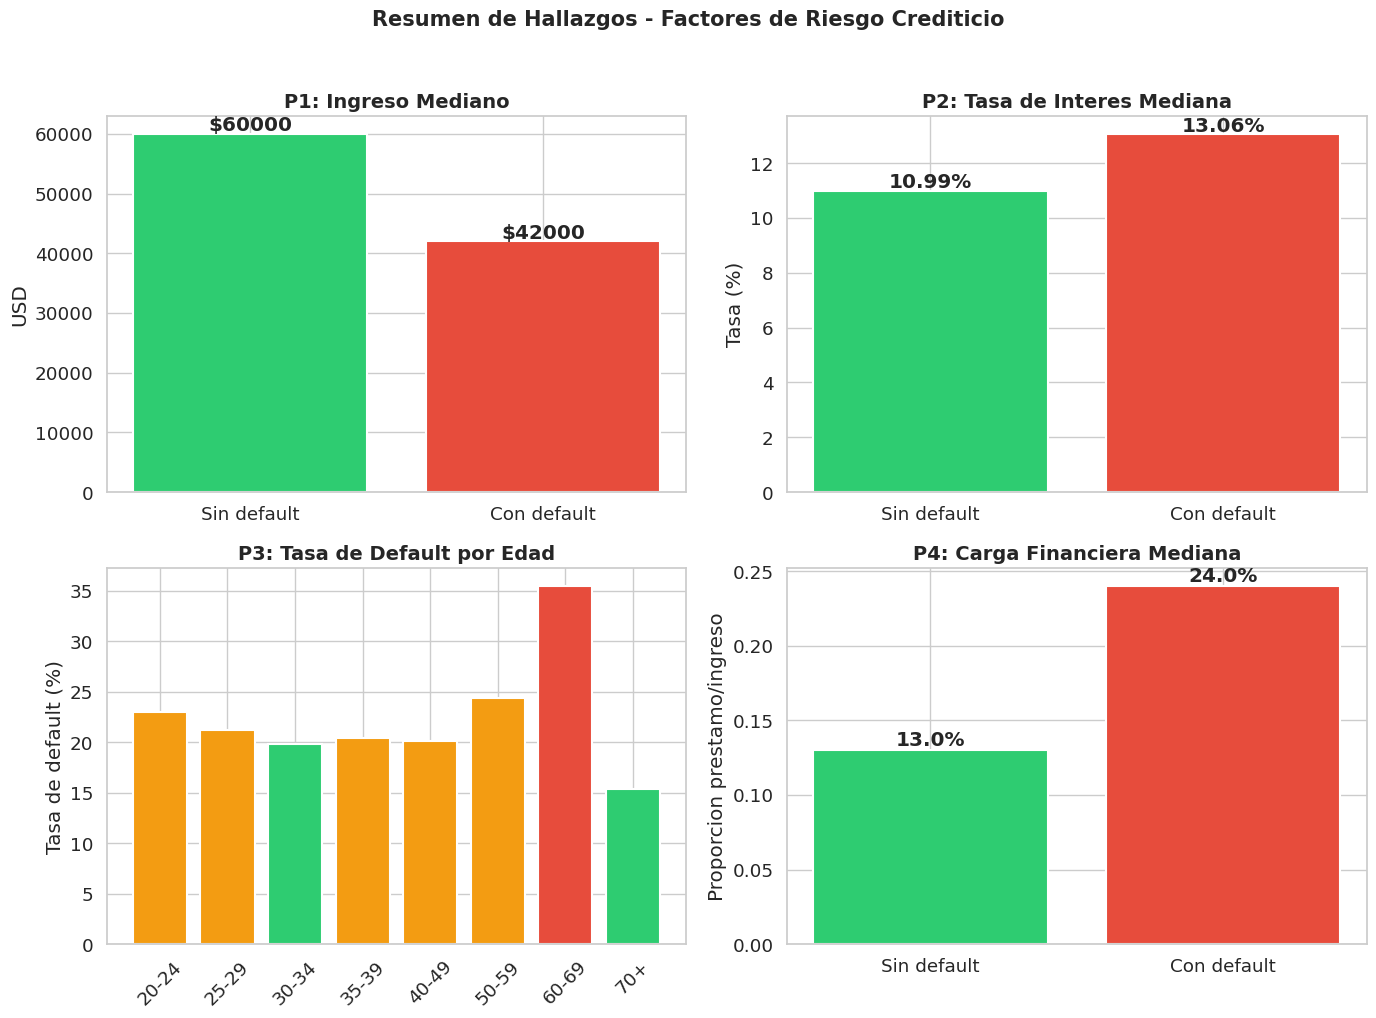

In [13]:
# ============================================================
# CELDA 10 - Resumen visual de hallazgos
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Datos para los 4 graficos resumen
categorias = ['Sin default', 'Con default']
colores = ['#2ecc71', '#e74c3c']

# Grafico 1 - Ingreso mediano
ingresos = [60000, 42000]
axes[0, 0].bar(categorias, ingresos, color=colores, edgecolor='white', linewidth=1.5)
axes[0, 0].set_title('P1: Ingreso Mediano')
axes[0, 0].set_ylabel('USD')
for i, v in enumerate(ingresos):
    axes[0, 0].text(i, v + 500, '$' + str(v), ha='center', fontweight='bold')

# Grafico 2 - Tasa de interes mediana
tasas = [10.99, 13.06]
axes[0, 1].bar(categorias, tasas, color=colores, edgecolor='white', linewidth=1.5)
axes[0, 1].set_title('P2: Tasa de Interes Mediana')
axes[0, 1].set_ylabel('Tasa (%)')
for i, v in enumerate(tasas):
    axes[0, 1].text(i, v + 0.1, str(v) + '%', ha='center', fontweight='bold')

# Grafico 3 - Tasa default por edad
tasa_edad = df.groupby('rango_edad', observed=True)['loan_status'].mean() * 100
colores_edad = ['#e74c3c' if t > 25 else '#f39c12' if t > 20 else '#2ecc71'
                for t in tasa_edad.values]
axes[1, 0].bar(tasa_edad.index, tasa_edad.values,
               color=colores_edad, edgecolor='white', linewidth=1.5)
axes[1, 0].set_title('P3: Tasa de Default por Edad')
axes[1, 0].set_ylabel('Tasa de default (%)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Grafico 4 - Carga financiera mediana
cargas = [0.13, 0.24]
axes[1, 1].bar(categorias, cargas, color=colores, edgecolor='white', linewidth=1.5)
axes[1, 1].set_title('P4: Carga Financiera Mediana')
axes[1, 1].set_ylabel('Proporcion prestamo/ingreso')
for i, v in enumerate(cargas):
    axes[1, 1].text(i, v + 0.003, str(round(v*100, 0)) + '%',
                    ha='center', fontweight='bold')

plt.suptitle('Resumen de Hallazgos - Factores de Riesgo Crediticio',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz6_resumen_hallazgos.png', dpi=150, bbox_inches='tight')
plt.show()

## Insights y Conclusiones

### Respuesta a las preguntas de investigacion

**P1 - Ingreso del solicitante:**
Confirmada. Los clientes que entran en default tienen una mediana
de ingreso de $42.000 versus $60.000 de los que pagan correctamente.
Una diferencia de $18.000 (-30%) estadisticamente significativa.

**P2 - Tasa de interes:**
Confirmada. Los prestamos en default tienen una tasa mediana de 13.06%
versus 10.99% en prestamos pagados. Mayor tasa implica mayor cuota
mensual y mayor presion financiera sobre el solicitante.

**P3 - Edad del solicitante:**
Parcialmente confirmada. La relacion no es lineal sino en forma de U.
Jovenes (20-24 anos) y adultos mayores (60-69 anos) presentan las
tasas de default mas altas. El grupo de menor riesgo es el de 30-39 anos.

**P4 - Carga financiera:**
Confirmada con la evidencia mas fuerte. Los clientes en default
destinan el 24% de su ingreso al prestamo versus el 13% de los
que pagan. Una diferencia relativa de 84.6%.

### Insight principal
El factor mas predictivo de default es la proporcion del prestamo
sobre el ingreso. Una entidad financiera que limite esta proporcion
al 20% podria reducir significativamente su exposicion al riesgo
sin excluir a la mayoria de solicitantes validos.

### Limitaciones
- El dataset no incluye historial crediticio completo
- Variables como patrimonio neto o gastos fijos no estan disponibles
- Los datos pueden no ser representativos de otros mercados fuera de EE.UU.

In [14]:
# ============================================================
# CELDA EXPORTACION - Verificar imagenes guardadas
# ============================================================

import os

imagenes = [
    'viz1_distribucion_default.png',
    'viz2_ingreso_default.png',
    'viz3_tasa_default.png',
    'viz4_edad_default.png',
    'viz5_carga_default.png',
    'viz6_resumen_hallazgos.png'
]

print("IMAGENES DISPONIBLES:")
for img in imagenes:
    existe = os.path.exists(img)
    estado = "OK" if existe else "NO ENCONTRADA"
    print("   " + img + ": " + estado)

IMAGENES DISPONIBLES:
   viz1_distribucion_default.png: OK
   viz2_ingreso_default.png: OK
   viz3_tasa_default.png: OK
   viz4_edad_default.png: OK
   viz5_carga_default.png: OK
   viz6_resumen_hallazgos.png: OK


In [17]:
# CELDA DESCARGA - Descargar imagenes a tu computadora
from google.colab import files

for img in imagenes:
    if os.path.exists(img):
        files.download(img)
        print("Descargando: " + img)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: viz1_distribucion_default.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Descargando: viz5_carga_default.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando: viz6_resumen_hallazgos.png
